In [6]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

PROCESSED_DIR = Path('../data/processed')
SPLIT_FILE = Path('../raw_data/nslt_100.json')

with open(SPLIT_FILE) as f:
    split_data = json.load(f)

# Map video_id -> (label_index, gloss) using the split file
# action[0] is the numeric label; we also want the human-readable gloss from WLASL
wlasl_file = Path('../raw_data/WLASL_v0.3.json') if Path('../raw_data/WLASL_v0.3.json').exists() \
             else Path('../../WLASL/start_kit/WLASL_v0.3.json')
with open(wlasl_file) as f:
    wlasl_data = json.load(f)

label_to_gloss = {}
for entry in wlasl_data:
    for inst in entry['instances']:
        vid = inst['video_id']
        if vid in split_data:
            label_to_gloss[split_data[vid]['action'][0]] = entry['gloss']

# Collect all processed samples
npy_files = sorted(PROCESSED_DIR.glob('*.npy'))
records = []
for p in npy_files:
    vid_id = p.stem
    if vid_id not in split_data:
        continue
    arr = np.load(p)          # shape (T, 63)
    label = split_data[vid_id]['action'][0]
    subset = split_data[vid_id]['subset']
    records.append({'vid_id': vid_id, 'arr': arr, 'label': label,
                    'gloss': label_to_gloss.get(label, '?'), 'subset': subset})

frame_counts = [r['arr'].shape[0] for r in records]
labels       = [r['label'] for r in records]

print(f"Processed files found : {len(records)}")
print(f"Unique word classes   : {len(set(labels))}")
print(f"Subsets               : {dict(Counter(r['subset'] for r in records))}")
print()
print(f"Frames per video — min: {min(frame_counts)}  max: {max(frame_counts)}  "
      f"mean: {np.mean(frame_counts):.1f}  median: {np.median(frame_counts):.0f}")

all_vals = np.concatenate([r['arr'] for r in records])
print(f"\nLandmark values — min: {all_vals.min():.4f}  max: {all_vals.max():.4f}")
print(f"Any NaN: {np.isnan(all_vals).any()}")
print(f"All-zero frames (no hand detected): "
      f"{(~all_vals.any(axis=1)).sum()} / {len(all_vals)}")

Processed files found : 1465
Unique word classes   : 100
Subsets               : {'train': 1021, 'test': 201, 'val': 243}

Frames per video — min: 19  max: 195  mean: 69.5  median: 70

Landmark values — min: -0.2135  max: 1.1593
Any NaN: False
All-zero frames (no hand detected): 39971 / 101839


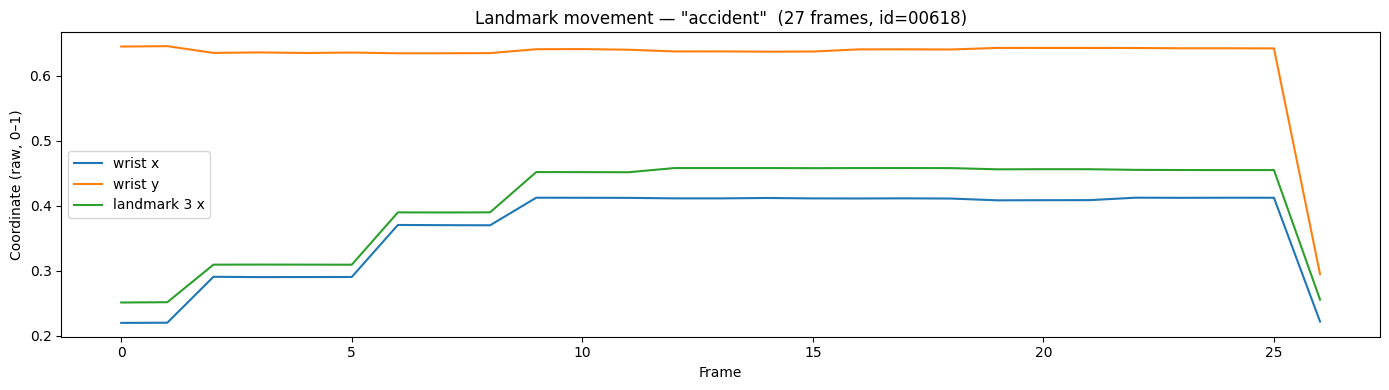

In [7]:
# Plot 1 — landmark movement over time for a real sample
sample = records[0]
arr = sample['arr']   # shape (T, 63)

plt.figure(figsize=(14, 4))
plt.plot(arr[:, 0], label='wrist x')
plt.plot(arr[:, 1], label='wrist y')
plt.plot(arr[:, 9], label='landmark 3 x')
plt.title(f"Landmark movement — \"{sample['gloss']}\"  ({arr.shape[0]} frames, id={sample['vid_id']})")
plt.xlabel("Frame")
plt.ylabel("Coordinate (raw, 0–1)")
plt.legend()
plt.tight_layout()
plt.show()

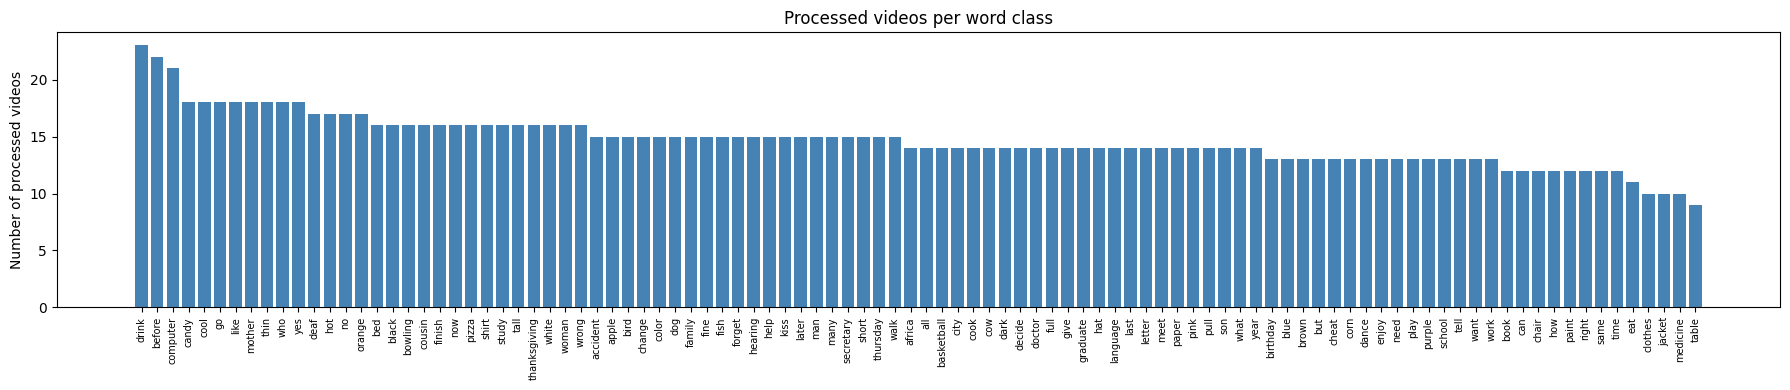

Min: 9 (table)
Max: 23 (drink)


In [8]:
# Plot 2 — videos per word class (sorted)
class_counts = Counter(r['gloss'] for r in records)
sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
names, counts = zip(*sorted_classes)

plt.figure(figsize=(18, 4))
plt.bar(names, counts, color='steelblue')
plt.xticks(rotation=90, fontsize=7)
plt.ylabel("Number of processed videos")
plt.title("Processed videos per word class")
plt.tight_layout()
plt.show()

print(f"Min: {min(counts)} ({names[counts.index(min(counts))]})")
print(f"Max: {max(counts)} ({names[0]})")

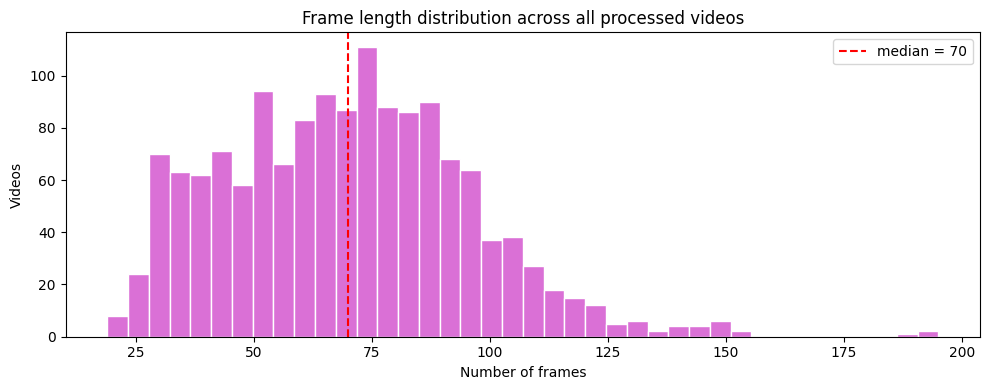

Videos where >50% of frames have no hand detected:
  00624  accident         56% zero frames  (109 frames total)
  00639  accident         60% zero frames  (105 frames total)
  01383  africa           70% zero frames  (146 frames total)
  01393  africa           56% zero frames  (72 frames total)
  05230  basketball       53% zero frames  (97 frames total)
  05243  basketball       60% zero frames  (80 frames total)
  05638  bed              53% zero frames  (36 frames total)
  05641  bed              60% zero frames  (94 frames total)
  05644  bed              63% zero frames  (84 frames total)
  05749  before           72% zero frames  (90 frames total)
  05750  before           62% zero frames  (100 frames total)
  06331  bird             57% zero frames  (63 frames total)
  06332  bird             53% zero frames  (91 frames total)
  06334  bird             58% zero frames  (19 frames total)
  06335  bird             52% zero frames  (111 frames total)
  06343  bird             54%

In [9]:
# Plot 3 — frame length distribution (tells you what sequence length to pad/truncate to)
plt.figure(figsize=(10, 4))
plt.hist(frame_counts, bins=40, color='orchid', edgecolor='white')
plt.axvline(np.median(frame_counts), color='red', linestyle='--', label=f'median = {np.median(frame_counts):.0f}')
plt.xlabel("Number of frames")
plt.ylabel("Videos")
plt.title("Frame length distribution across all processed videos")
plt.legend()
plt.tight_layout()
plt.show()

# Videos with high zero-frame rate (hand never detected) — worth reviewing
print("Videos where >50% of frames have no hand detected:")
for r in records:
    zero_rate = (~r['arr'].any(axis=1)).mean()
    if zero_rate > 0.5:
        print(f"  {r['vid_id']}  {r['gloss']:<15}  {zero_rate:.0%} zero frames  ({r['arr'].shape[0]} frames total)")